<a href="https://colab.research.google.com/github/toufiqrifat/parkinson-s-finger-tapping-/blob/main/parkinsons_finger_tapping_clean_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Finger Tapping Sequence Export Pipeline
This notebook keeps the dataset upload point, cleans and normalises each tapping signal, and exports **step-by-step sequence data** with **diagnosis labels** for LSTM modelling.

In [1]:

# 1. Imports
import os
import re
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)


## Dataset upload / extraction point

In [2]:

# 2. Keep the dataset upload point
left_zip_path = "/content/LEFT HANDS-20260114T231306Z-1-001.zip"
right_zip_path = "/content/RIGHT HANDS-20260114T231452Z-1-001.zip"

extract_base = "/mnt/data/extracted_sequence"
LEFT_BASE = os.path.join(extract_base, "LEFT")
RIGHT_BASE = os.path.join(extract_base, "RIGHT")

os.makedirs(LEFT_BASE, exist_ok=True)
os.makedirs(RIGHT_BASE, exist_ok=True)

with zipfile.ZipFile(left_zip_path, "r") as zip_ref:
    zip_ref.extractall(LEFT_BASE)

with zipfile.ZipFile(right_zip_path, "r") as zip_ref:
    zip_ref.extractall(RIGHT_BASE)

print("LEFT data extracted to:", LEFT_BASE)
print("RIGHT data extracted to:", RIGHT_BASE)
print("LEFT subjects/folders sample:", os.listdir(LEFT_BASE)[:5])
print("RIGHT subjects/folders sample:", os.listdir(RIGHT_BASE)[:5])


LEFT data extracted to: /mnt/data/extracted_sequence/LEFT
RIGHT data extracted to: /mnt/data/extracted_sequence/RIGHT
LEFT subjects/folders sample: ['LEFT HANDS']
RIGHT subjects/folders sample: ['RIGHT HANDS']


## File loading and preprocessing helpers

In [3]:

# 3. File discovery and robust loading

def get_all_signal_files(base_path, extensions=(".txt", ".csv", ".dat")):
    signal_files = []
    valid_ext = tuple(ext.lower() for ext in extensions)
    for root, _, files in os.walk(base_path):
        for file in files:
            if file.lower().endswith(valid_ext):
                signal_files.append(os.path.join(root, file))
    return sorted(signal_files)


def load_signal(file_path):
    """
    Robust loader for 1D numeric signals.
    Supports common delimiters and flattens the result into one sequence.
    """
    candidates = [None, ",", ";", "\t", " "]

    for delimiter in candidates:
        try:
            data = np.genfromtxt(file_path, delimiter=delimiter, dtype=float)
            if data is None:
                continue
            data = np.asarray(data, dtype=float)
            if data.size == 0:
                continue
            data = data.reshape(-1)
            if np.all(np.isnan(data)):
                continue
            return data
        except Exception:
            continue

    print(f"Could not load: {file_path}")
    return None


def make_valid_odd_window(signal_length, desired_window=11):
    if signal_length < 3:
        return None

    window = min(desired_window, signal_length)
    if window % 2 == 0:
        window -= 1
    if window < 3:
        return None
    return window


def clean_and_normalise_signal(signal, desired_window=11, polyorder=2):
    """
    Cleaning pipeline:
    1. Remove invalid values
    2. Clip extreme outliers with IQR
    3. Smooth with Savitzky-Golay
    4. Min-Max normalise to [0, 1]
    """
    if signal is None:
        return None, None

    signal = np.asarray(signal, dtype=float).reshape(-1)
    raw_clean = signal[np.isfinite(signal)]

    if raw_clean.size < 3:
        return None, None

    q1, q3 = np.percentile(raw_clean, [25, 75])
    iqr = q3 - q1

    if iqr == 0:
        processed = raw_clean.copy()
    else:
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        processed = np.clip(raw_clean, lower, upper)

    window = make_valid_odd_window(len(processed), desired_window=desired_window)
    if window is not None and window > polyorder:
        processed = savgol_filter(processed, window_length=window, polyorder=polyorder)

    scaler = MinMaxScaler(feature_range=(0, 1))
    normalised = scaler.fit_transform(processed.reshape(-1, 1)).reshape(-1)

    return processed, normalised


In [4]:

# 4. Metadata helpers for diagnosis and subject identity

def infer_diagnosis_from_path(file_path):
    """
    Infer diagnosis from folder/file names.
    Edit the keyword lists below if your dataset uses different naming.
    """
    path_lower = file_path.lower()

    parkinsons_keywords = [
        "parkinson", "parkinsons", "pd", "patient", "disease"
    ]
    healthy_keywords = [
        "healthy", "control", "hc", "normal"
    ]

    if any(keyword in path_lower for keyword in parkinsons_keywords):
        return "Parkinson's"
    if any(keyword in path_lower for keyword in healthy_keywords):
        return "Healthy"

    return "Unknown"


def extract_subject_id(file_path):
    """
    Try to recover a subject/person ID from folder or file names.
    Falls back to filename stem if no clearer ID is found.
    """
    norm_path = os.path.normpath(file_path)
    parts = norm_path.split(os.sep)

    # Prefer nearest folder names that look like participant IDs
    candidate_parts = list(reversed(parts[:-1])) + [os.path.splitext(os.path.basename(file_path))[0]]

    patterns = [
        r'(subject[_\- ]?\d+)',
        r'(participant[_\- ]?\d+)',
        r'(person[_\- ]?\d+)',
        r'(patient[_\- ]?\d+)',
        r'(control[_\- ]?\d+)',
        r'(hc[_\- ]?\d+)',
        r'(pd[_\- ]?\d+)',
        r'([a-z]{1,4}\d{2,})'
    ]

    for part in candidate_parts:
        clean_part = part.strip()
        for pattern in patterns:
            match = re.search(pattern, clean_part, flags=re.IGNORECASE)
            if match:
                return match.group(1).replace(" ", "_")

    return os.path.splitext(os.path.basename(file_path))[0]


def determine_hand_label(file_path):
    path_lower = file_path.lower()
    if "left" in path_lower:
        return "left"
    if "right" in path_lower:
        return "right"
    return "unknown"


## Evidence plots

In [5]:

# 5. Plot helper for report evidence

def plot_raw_vs_clean_vs_normalised(raw_signal, cleaned_signal, normalised_signal, title_prefix="Signal"):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)

    axes[0].plot(raw_signal)
    axes[0].set_title(f"{title_prefix} - Raw")

    axes[1].plot(cleaned_signal)
    axes[1].set_title(f"{title_prefix} - Cleaned")

    axes[2].plot(normalised_signal)
    axes[2].set_title(f"{title_prefix} - Normalised (0 to 1)")
    axes[2].set_xlabel("Time step")

    plt.tight_layout()
    plt.show()


def save_comparison_figure(raw_signal, cleaned_signal, normalised_signal, save_path, title_prefix="Signal"):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=False)

    axes[0].plot(raw_signal)
    axes[0].set_title(f"{title_prefix} - Raw")

    axes[1].plot(cleaned_signal)
    axes[1].set_title(f"{title_prefix} - Cleaned")

    axes[2].plot(normalised_signal)
    axes[2].set_title(f"{title_prefix} - Normalised (0 to 1)")
    axes[2].set_xlabel("Time step")

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.close()


## Preview one sample before exporting the full sequence dataset

LEFT files: 392
RIGHT files: 394
ALL files: 786
Sample file: /mnt/data/extracted_sequence/LEFT/LEFT HANDS/C1/Text files/Amplitude.txt
Diagnosis inferred: Unknown
Subject ID: Amplitude
Hand: left
Raw length: 1756
Cleaned length: 1756
Normalised range: 0.0 to 1.0


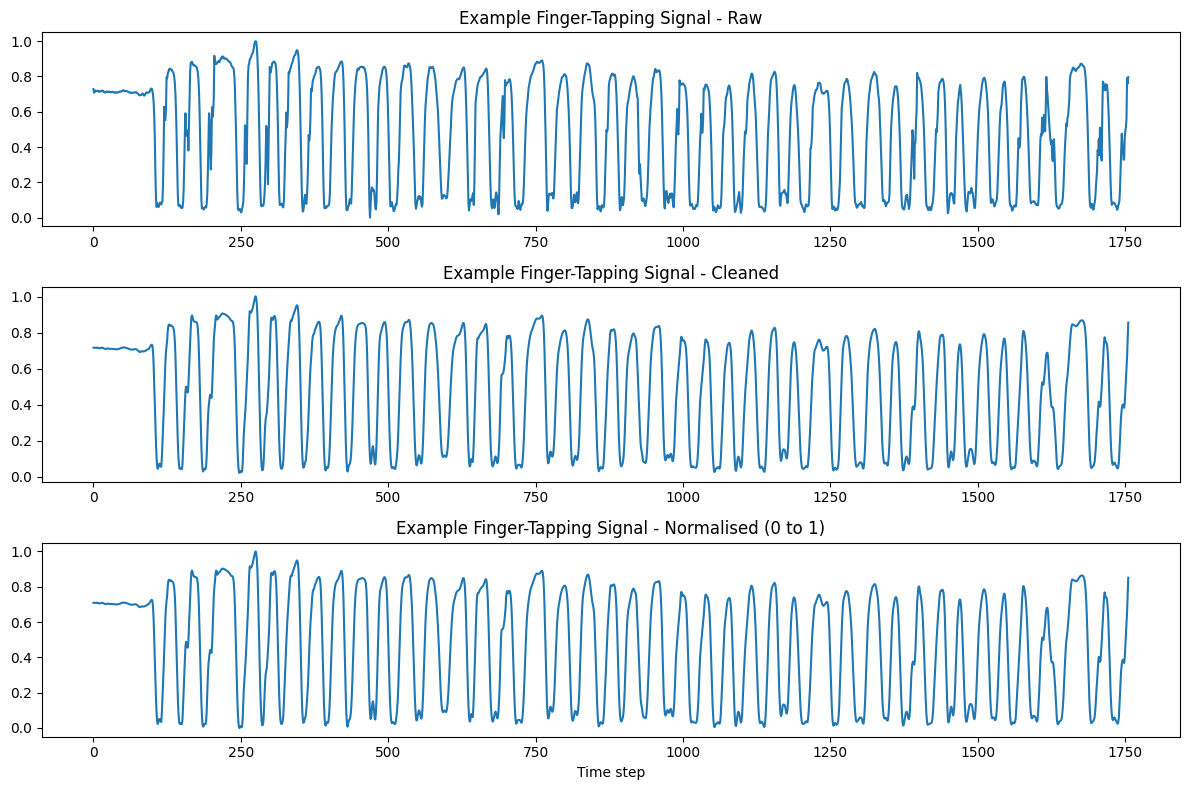

Saved evidence figure to: /mnt/data/raw_clean_normalised_comparison_sequence.png


In [6]:

# 6. Discover files and preview one sample

left_files = get_all_signal_files(LEFT_BASE)
right_files = get_all_signal_files(RIGHT_BASE)
all_files = left_files + right_files

print("LEFT files:", len(left_files))
print("RIGHT files:", len(right_files))
print("ALL files:", len(all_files))

sample_file = all_files[0] if all_files else None

if sample_file:
    raw_signal = load_signal(sample_file)
    cleaned_signal, normalised_signal = clean_and_normalise_signal(raw_signal)

    print("Sample file:", sample_file)
    print("Diagnosis inferred:", infer_diagnosis_from_path(sample_file))
    print("Subject ID:", extract_subject_id(sample_file))
    print("Hand:", determine_hand_label(sample_file))

    if raw_signal is not None and cleaned_signal is not None and normalised_signal is not None:
        print("Raw length:", len(raw_signal))
        print("Cleaned length:", len(cleaned_signal))
        print("Normalised range:", float(np.min(normalised_signal)), "to", float(np.max(normalised_signal)))

        plot_raw_vs_clean_vs_normalised(
            raw_signal,
            cleaned_signal,
            normalised_signal,
            title_prefix="Example Finger-Tapping Signal"
        )

        evidence_path = "/mnt/data/raw_clean_normalised_comparison_sequence.png"
        save_comparison_figure(
            raw_signal,
            cleaned_signal,
            normalised_signal,
            evidence_path,
            title_prefix="Example Finger-Tapping Signal"
        )
        print("Saved evidence figure to:", evidence_path)
    else:
        print("Sample file could not be cleaned.")
else:
    print("No files found. Check upload and extraction paths.")


## Build sequence datasets for LSTM

In [7]:

# 7. Create long-format sequence data with diagnosis attached

def build_sequence_dataframe(file_list):
    """
    Output format:
    one row = one time step from one recording
    This is ideal for inspection and can be reshaped later for sequence models.
    """
    rows = []

    for file_path in file_list:
        raw_signal = load_signal(file_path)
        cleaned_signal, normalised_signal = clean_and_normalise_signal(raw_signal)

        if raw_signal is None or normalised_signal is None or len(normalised_signal) < 3:
            continue

        diagnosis = infer_diagnosis_from_path(file_path)
        subject_id = extract_subject_id(file_path)
        hand = determine_hand_label(file_path)
        recording_id = os.path.splitext(os.path.basename(file_path))[0]

        for time_step, value in enumerate(normalised_signal):
            rows.append({
                "subject_id": subject_id,
                "recording_id": recording_id,
                "diagnosis": diagnosis,
                "hand": hand,
                "time_step": int(time_step),
                "tap_value": float(value),
                "original_length": int(len(raw_signal)),
                "processed_length": int(len(normalised_signal)),
                "source_file": file_path
            })

    return pd.DataFrame(rows)


sequence_long_df = build_sequence_dataframe(all_files)

print("Long-format sequence dataset shape:", sequence_long_df.shape)
display(sequence_long_df.head(20))


Long-format sequence dataset shape: (1059984, 9)


,subject_id,recording_id,diagnosis,hand,time_step,tap_value,original_length,processed_length,source_file
0,Amplitude,Amplitude,Unknown,left,0,0.708722,1756,1756,/mnt/data/extracted_sequence/LEFT/LEFT HANDS/C...
1,Amplitude,Amplitude,Unknown,left,1,0.708725,1756,1756,/mnt/data/extracted_sequence/LEFT/LEFT HANDS/C...
2,Amplitude,Amplitude,Unknown,left,2,0.708656,1756,1756,/mnt/data/extracted_sequence/LEFT/LEFT HANDS/C...
3,Amplitude,Amplitude,Unknown,left,3,0.708516,1756,1756,/mnt/data/extracted_sequence/LEFT/LEFT HANDS/C...
4,Amplitude,Amplitude,Unknown,left,4,0.708305,1756,1756,/mnt/data/extracted_sequence/LEFT/LEFT HANDS/C...
5,Amplitude,Amplitude,Unknown,left,5,0.708022,1756,1756,/mnt/data/extracted_sequence/LEFT/LEFT HANDS/C...
6,Amplitude,Amplitude,Unknown,left,6,0.709895,1756,1756,/mnt/data/extracted_sequence/LEFT/LEFT HANDS/C...
7,Amplitude,Amplitude,Unknown,left,7,0.708596,1756,1756,/mnt/data/extracted_sequence/LEFT/LEFT HANDS/C...
8,Amplitude,Amplitude,Unknown,left,8,0.707265,1756,1756,/mnt/data/extracted_sequence/LEFT/LEFT HANDS/C...
9,Amplitude,Amplitude,Unknown,left,9,0.706329,1756,1756,/mnt/data/extracted_sequence/LEFT/LEFT HANDS/C...


In [8]:

# 8. Build padded wide-format sequences for direct LSTM input preparation

def build_padded_sequence_dataframe(sequence_long_df, padding_value=0.0):
    """
    Output format:
    one row = one recording
    columns tap_0000, tap_0001, ... contain the time-ordered sequence.
    This format is convenient for export and later reshaping to 3D for LSTM.
    """
    if sequence_long_df.empty:
        return pd.DataFrame()

    grouped = sequence_long_df.groupby(["subject_id", "recording_id", "diagnosis", "hand", "source_file"], sort=False)
    max_len = int(grouped["time_step"].max().max() + 1)

    padded_rows = []
    for keys, group in grouped:
        subject_id, recording_id, diagnosis, hand, source_file = keys
        seq = group.sort_values("time_step")["tap_value"].to_numpy(dtype=float)

        padded = np.full(max_len, padding_value, dtype=float)
        padded[:len(seq)] = seq

        row = {
            "subject_id": subject_id,
            "recording_id": recording_id,
            "diagnosis": diagnosis,
            "hand": hand,
            "sequence_length": int(len(seq)),
            "source_file": source_file
        }

        for i, val in enumerate(padded):
            row[f"tap_{i:04d}"] = float(val)

        padded_rows.append(row)

    return pd.DataFrame(padded_rows)


sequence_padded_df = build_padded_sequence_dataframe(sequence_long_df)

print("Padded sequence dataset shape:", sequence_padded_df.shape)
display(sequence_padded_df.iloc[:5, :12])


Padded sequence dataset shape: (786, 1806)


,subject_id,recording_id,diagnosis,hand,sequence_length,source_file,tap_0000,tap_0001,tap_0002,tap_0003,tap_0004,tap_0005
0,Amplitude,Amplitude,Unknown,left,1756,/mnt/data/extracted_sequence/LEFT/LEFT HANDS/C...,0.708722,0.708725,0.708656,0.708516,0.708305,0.708022
1,Rhythm,Rhythm,Unknown,left,39,/mnt/data/extracted_sequence/LEFT/LEFT HANDS/C...,0.313554,0.452368,0.560512,0.637984,0.684786,0.700917
2,Time,Time,Unknown,left,1756,/mnt/data/extracted_sequence/LEFT/LEFT HANDS/C...,0.000000,0.000556,0.001112,0.001668,0.002223,0.002779
3,Velocity,Velocity,Unknown,left,1755,/mnt/data/extracted_sequence/LEFT/LEFT HANDS/C...,0.463229,0.483120,0.499311,0.511801,0.520590,0.525679
4,C10,Amplitude,Unknown,left,1800,/mnt/data/extracted_sequence/LEFT/LEFT HANDS/C...,0.859425,0.865196,0.869944,0.873667,0.876366,0.878041


In [9]:

# 9. Before/after evidence tables for the report

if sample_file and raw_signal is not None and cleaned_signal is not None and normalised_signal is not None:
    before_df = pd.DataFrame({"raw_signal": raw_signal[:20]})
    after_df = pd.DataFrame({
        "cleaned_signal": cleaned_signal[:20],
        "normalised_signal": normalised_signal[:20]
    })

    print("Before normalisation (first 20 values):")
    display(before_df)

    print("After cleaning and normalisation (first 20 values):")
    display(after_df)
else:
    before_df = pd.DataFrame()
    after_df = pd.DataFrame()
    print("No sample data available for before/after evidence.")


Before normalisation (first 20 values):


,raw_signal
0,0.728334
1,0.707412
2,0.711294
3,0.717946
4,0.720615
5,0.717337
6,0.717561
7,0.718587
8,0.719047
9,0.713244


After cleaning and normalisation (first 20 values):


,cleaned_signal,normalised_signal
0,0.717752,0.708722
1,0.717755,0.708725
2,0.717688,0.708656
3,0.717551,0.708516
4,0.717343,0.708305
5,0.717066,0.708022
6,0.718904,0.709895
7,0.717629,0.708596
8,0.716323,0.707265
9,0.715405,0.706329


## Optional quality check

In [10]:

# 10. Quick label check

if not sequence_long_df.empty:
    print("Diagnosis counts:")
    print(sequence_long_df[["recording_id", "diagnosis"]].drop_duplicates()["diagnosis"].value_counts(dropna=False))
else:
    print("Sequence dataset is empty.")


Diagnosis counts:
diagnosis
Parkinson's    6
Unknown        4
Name: count, dtype: int64


## Save outputs

In [11]:

# 11. Save export files

output_paths = {}

if not sequence_long_df.empty:
    long_output = "/mnt/data/finger_tapping_sequences_long.csv"
    sequence_long_df.to_csv(long_output, index=False)
    output_paths["long_sequence_csv"] = long_output
    print("Saved long-format sequence dataset to:", long_output)

if not sequence_padded_df.empty:
    padded_output = "/mnt/data/finger_tapping_sequences_padded.csv"
    sequence_padded_df.to_csv(padded_output, index=False)
    output_paths["padded_sequence_csv"] = padded_output
    print("Saved padded sequence dataset to:", padded_output)

if not before_df.empty:
    before_output = "/mnt/data/before_normalisation_sample.csv"
    after_output = "/mnt/data/after_normalisation_sample.csv"
    before_df.to_csv(before_output, index=False)
    after_df.to_csv(after_output, index=False)
    output_paths["before_sample_csv"] = before_output
    output_paths["after_sample_csv"] = after_output
    print("Saved before/after normalisation samples.")

print("Output paths:", output_paths)


Saved long-format sequence dataset to: /mnt/data/finger_tapping_sequences_long.csv
Saved padded sequence dataset to: /mnt/data/finger_tapping_sequences_padded.csv
Saved before/after normalisation samples.
Output paths: {'long_sequence_csv': '/mnt/data/finger_tapping_sequences_long.csv', 'padded_sequence_csv': '/mnt/data/finger_tapping_sequences_padded.csv', 'before_sample_csv': '/mnt/data/before_normalisation_sample.csv', 'after_sample_csv': '/mnt/data/after_normalisation_sample.csv'}


## Report paragraph

In [12]:

report_paragraph = """
The raw finger-tapping signal files were first extracted from the uploaded dataset folders and loaded into Python as one-dimensional numeric arrays. During preprocessing, invalid values such as missing entries, non-numeric values, and infinite values were removed to improve data quality. To reduce the effect of recording errors and abnormal spikes, the signals were clipped using the interquartile range (IQR) method and then smoothed with a Savitzky-Golay filter, which preserves the overall shape of the motion pattern while removing high-frequency noise. After cleaning, Min-Max normalisation was applied to each signal so that all values were scaled between 0 and 1. For LSTM preparation, the processed data was exported as a step-by-step time-series dataset in which each row retained the subject identifier, recording identifier, diagnosis label, hand label, and the ordered tap value at each time step. A padded sequence version was also exported so that each recording could be represented as one fixed-length sequence for direct model input. To provide evidence of preprocessing, the dataset was presented both before and after normalisation using comparison plots and sample tables.
"""
print(report_paragraph)



The raw finger-tapping signal files were first extracted from the uploaded dataset folders and loaded into Python as one-dimensional numeric arrays. During preprocessing, invalid values such as missing entries, non-numeric values, and infinite values were removed to improve data quality. To reduce the effect of recording errors and abnormal spikes, the signals were clipped using the interquartile range (IQR) method and then smoothed with a Savitzky-Golay filter, which preserves the overall shape of the motion pattern while removing high-frequency noise. After cleaning, Min-Max normalisation was applied to each signal so that all values were scaled between 0 and 1. For LSTM preparation, the processed data was exported as a step-by-step time-series dataset in which each row retained the subject identifier, recording identifier, diagnosis label, hand label, and the ordered tap value at each time step. A padded sequence version was also exported so that each recording could be represented